# Ablation 3 — Parallel Residuals

Sweeps `parallel_start_layer` ∈ {−1, 7, 4, 0} (1 seed, 5 000 steps, warmdown 750).

| config | meaning |
|---|---|
| `psl = −1` | disabled — standard sequential residual stream (intra-ablation baseline) |
| `psl = 7` | parallel from layer 7 — last 2 of 9 layers (mirrors leaderboard entry, 1.1063 BPB) |
| `psl = 4` | parallel from layer 4 — full decoder half |
| `psl = 0` | all 9 layers parallel |

**Parallel residuals** replace the standard sequential transformer block — where attention and MLP are applied one after the other and each adds to the same residual stream — with two independent lanes that run in parallel. Each layer maintains a separate hidden state for attention and for MLP; the outputs are mixed back together via a learned 2×2 routing matrix before being written to the residual stream. A scalar `λ_resid` per lane controls how strongly each sub-block's output is blended in. The key hyperparameter is `parallel_start_layer`: layers before it remain sequential, while layers from it onward use the parallel two-lane design.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import wandb
import importlib, utils
importlib.reload(utils)
from utils import apply_style, get_deep_palette

apply_style(force=True)
PALETTE = get_deep_palette()

ENTITY  = "the-golfers"
PROJECT = "ml_ai_project"

api = wandb.Api()

# Human-readable labels and display order
PSL_ORDER  = [-1, 7, 4, 0]
PSL_LABELS = {
    -1: "Sequential (disabled)",
    7:  "Parallel L7+ (last 2)",
    4:  "Parallel L4+ (decoder)",
    0:  "Parallel L0+ (all)",
}
PSL_COLORS = {psl: PALETTE[i] for i, psl in enumerate(PSL_ORDER)}

## Original Baseline (3 seeds, reference)

In [7]:
BASELINE_PREFIX = "golf_baseline_antonio_new"

baseline_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{BASELINE_PREFIX}"}},
))

baseline_rows = []
for run in baseline_runs:
    s = run.summary._json_dict
    baseline_rows.append({
        "seed":             run.config.get("seed"),
        "final_val_bpb":    s.get("final_val_bpb"),
        "final_val_loss":   s.get("final_val_loss"),
    })

df_base = pd.DataFrame(baseline_rows).sort_values("seed").reset_index(drop=True)
BASE_BPB_MEAN = df_base["final_val_bpb"].mean()
BASE_BPB_STD  = df_base["final_val_bpb"].std()

print("=" * 50)
print("ORIGINAL BASELINE  (3 seeds, warmdown 750)")
print("=" * 50)
print(df_base.to_string(index=False))
print(f"\nfinal_val_bpb : {BASE_BPB_MEAN:.4f} ± {BASE_BPB_STD:.4f}")
print("=" * 50)

ORIGINAL BASELINE  (3 seeds, warmdown 750)
 seed  final_val_bpb  final_val_loss
   42       1.311465        2.214354
  123       1.309002        2.210195
 1337       1.309833        2.211598

final_val_bpb : 1.3101 ± 0.0013


## Ablation 3 — Parallel Residuals

In [8]:
ABL3_PREFIX = "ablation3_parallel_residuals"

abl3_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{ABL3_PREFIX}"}},
))

rows = []
for run in abl3_runs:
    s   = run.summary._json_dict
    cfg = run.config
    psl = cfg.get("parallel_start_layer", -1)
    rows.append({
        "run_name":         run.name,
        "parallel_start_layer": psl,
        "label":            PSL_LABELS.get(psl, str(psl)),
        "seed":             cfg.get("seed"),
        "final_val_bpb":    s.get("final_val_bpb"),
        "final_val_loss":   s.get("final_val_loss"),
        "quant_file_bytes": s.get("quant_file_bytes"),
    })

df = (
    pd.DataFrame(rows)
    .assign(psl_order=lambda d: d["parallel_start_layer"].map({v: i for i, v in enumerate(PSL_ORDER)}))
    .sort_values("psl_order")
    .reset_index(drop=True)
    .drop(columns="psl_order")
)
df

,run_name,parallel_start_layer,label,seed,final_val_bpb,final_val_loss,quant_file_bytes
0,ablation3_parallel_residuals_psl_disabled_seed...,-1,Sequential (disabled),1337,1.308481,2.209316,15777118
1,ablation3_parallel_residuals_psl7_seed1337,7,Parallel L7+ (last 2),1337,1.305821,2.204825,15809064
2,ablation3_parallel_residuals_psl4_seed1337,4,Parallel L4+ (decoder),1337,1.303321,2.200603,15823924
3,ablation3_parallel_residuals_psl0_seed1337,0,Parallel L0+ (all),1337,1.307662,2.207932,15816379


In [9]:
best = df.loc[df["final_val_bpb"].idxmin()]
disabled = df[df["parallel_start_layer"] == -1].iloc[0]

print(f"Intra-ablation baseline (sequential) : {disabled['final_val_bpb']:.4f} bpb")
print(f"Best parallel config                 : {best['label']}")
print(f"  final_val_bpb                      : {best['final_val_bpb']:.4f}")
delta = disabled["final_val_bpb"] - best["final_val_bpb"]
print(f"  Δ vs sequential                    : {delta:+.4f} bpb  ({'better' if delta > 0 else 'worse'})")

Intra-ablation baseline (sequential) : 1.3085 bpb
Best parallel config                 : Parallel L4+ (decoder)
  final_val_bpb                      : 1.3033
  Δ vs sequential                    : +0.0052 bpb  (better)


### Final val_bpb — bar chart with baseline reference

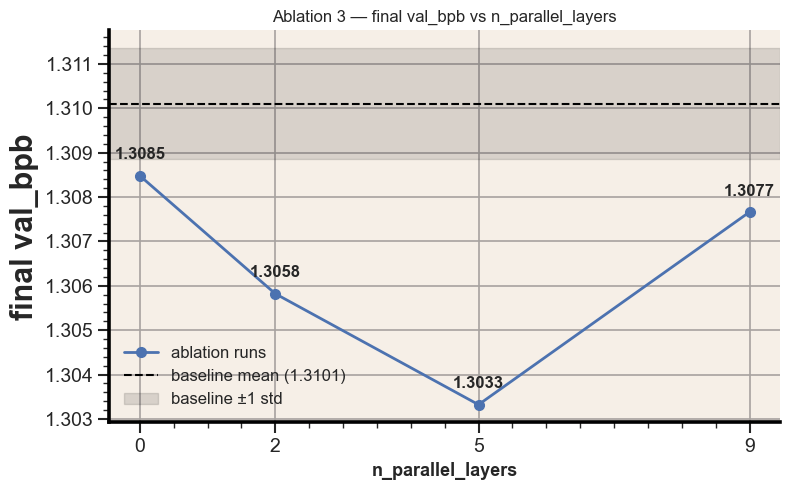

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

N_LAYERS = 9
n_parallel = [0 if psl == -1 else (N_LAYERS - psl) for psl in PSL_ORDER]
y_vals = [df.loc[df["parallel_start_layer"] == psl, "final_val_bpb"].values[0] for psl in PSL_ORDER]

ax.plot(n_parallel, y_vals, marker="o", color=PALETTE[0], linewidth=2, markersize=7, zorder=3,
        label="ablation runs")

for x, y in zip(n_parallel, y_vals):
    ax.text(x, y + 0.0003, f"{y:.4f}", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.axhline(BASE_BPB_MEAN, color="black", linewidth=1.5, linestyle="--",
           label=f"baseline mean ({BASE_BPB_MEAN:.4f})")
ax.axhspan(BASE_BPB_MEAN - BASE_BPB_STD, BASE_BPB_MEAN + BASE_BPB_STD,
           alpha=0.12, color="black", label="baseline ±1 std")

ax.set_xticks(n_parallel)
ax.set_xlabel("n_parallel_layers", fontsize=13, fontweight="bold")
ax.set_ylabel("final val_bpb")
ax.set_title("Ablation 3 — final val_bpb vs n_parallel_layers")
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

### Quantised model size vs n_parallel_layers

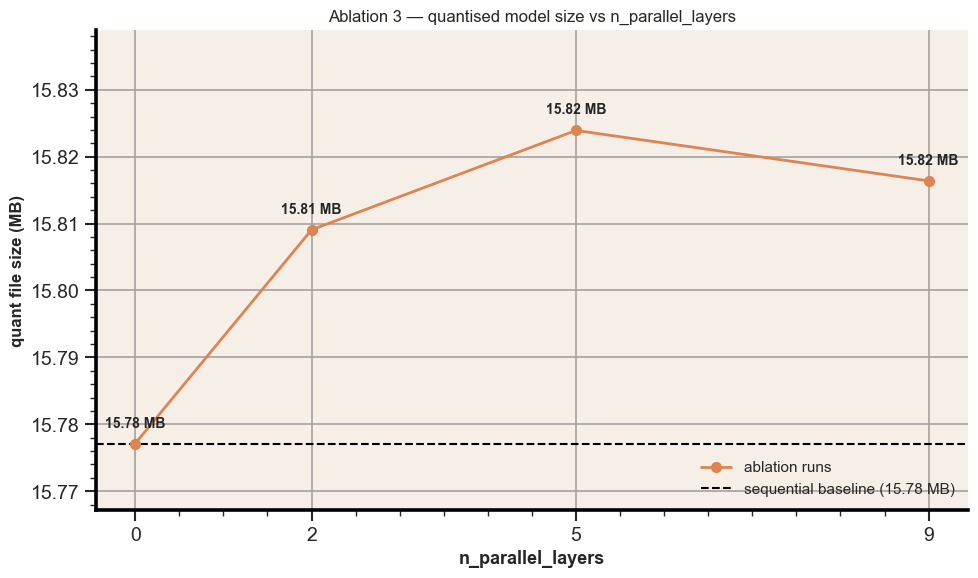

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

N_LAYERS = 9
n_parallel = [0 if psl == -1 else (N_LAYERS - psl) for psl in PSL_ORDER]
size_mb    = [df.loc[df["parallel_start_layer"] == psl, "quant_file_bytes"].values[0] / 1e6
              for psl in PSL_ORDER]

ax.plot(n_parallel, size_mb, marker="o", color=PALETTE[1], linewidth=2, markersize=7,
        zorder=3, label="ablation runs")

for x, y in zip(n_parallel, size_mb):
    ax.text(x, y + 0.002, f"{y:.2f} MB", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

# sequential (disabled) as reference line
seq_mb = df.loc[df["parallel_start_layer"] == -1, "quant_file_bytes"].values[0] / 1e6
ax.axhline(seq_mb, color="black", linewidth=1.5, linestyle="--",
           label=f"sequential baseline ({seq_mb:.2f} MB)")

ax.set_xticks(n_parallel)
ax.set_xlabel("n_parallel_layers", fontsize=13, fontweight="bold")
ax.set_ylabel("quant file size (MB)", fontsize=12)
ax.set_title("Ablation 3 — quantised model size vs n_parallel_layers", fontsize=12)
ymin = min(size_mb) - 0.01
ymax = max(size_mb) + 0.015
ax.set_ylim(ymin, ymax)
ax.legend(fontsize=11, loc="lower right")
plt.tight_layout(pad=1.5)
plt.show()

### Learning curves — val_bpb and train_loss

In [12]:
def fetch_history(runs, metric):
    """Returns {psl: DataFrame} sorted by PSL_ORDER."""
    histories = {}
    for run in runs:
        hist = run.history(keys=["_step", metric], pandas=True)
        if not hist.empty:
            hist = hist.rename(columns={"_step": "step"}).dropna()
            psl = run.config.get("parallel_start_layer", -1)
            histories[psl] = hist
    return {psl: histories[psl] for psl in PSL_ORDER if psl in histories}

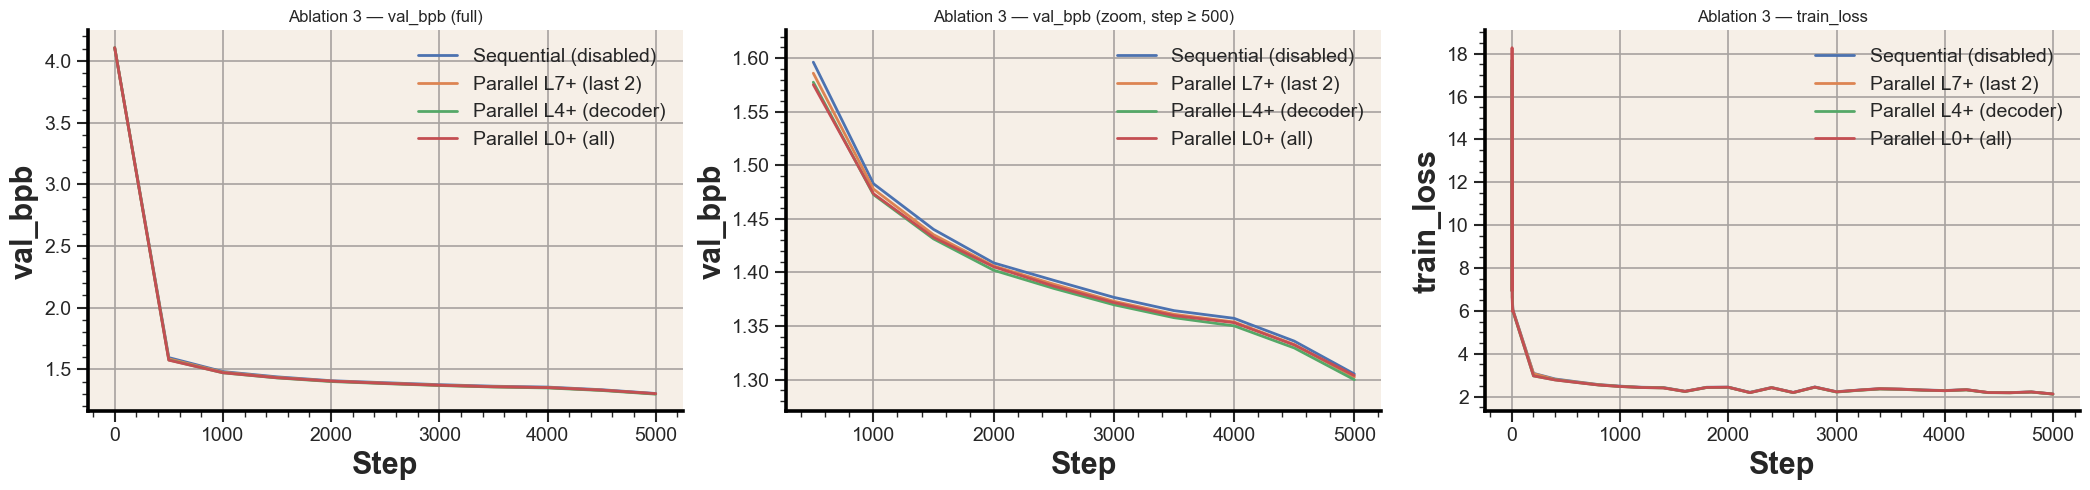

In [13]:
histories_bpb   = fetch_history(abl3_runs, "val_bpb")
histories_train = fetch_history(abl3_runs, "train_loss")

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# --- full val_bpb ---
ax = axes[0]
for psl, hist in histories_bpb.items():
    ax.plot(hist["step"], hist["val_bpb"],
            label=PSL_LABELS[psl], color=PSL_COLORS[psl], linewidth=2)
ax.set_xlabel("Step")
ax.set_ylabel("val_bpb")
ax.set_title("Ablation 3 — val_bpb (full)")
ax.legend()

# --- zoomed val_bpb (plateau region) ---
ax = axes[1]
ZOOM_STEP = 500          # ignore the steep drop-off before this step
for psl, hist in histories_bpb.items():
    h = hist[hist["step"] >= ZOOM_STEP]
    ax.plot(h["step"], h["val_bpb"],
            label=PSL_LABELS[psl], color=PSL_COLORS[psl], linewidth=2)
# tight y-limits around the plateau
all_vals = [h.loc[h["step"] >= ZOOM_STEP, "val_bpb"] for h in histories_bpb.values()]
ymin = min(v.min() for v in all_vals)
ymax = max(v.max() for v in all_vals)
pad  = (ymax - ymin) * 0.1
ax.set_ylim(ymin - pad, ymax + pad)
ax.set_xlabel("Step")
ax.set_ylabel("val_bpb")
ax.set_title(f"Ablation 3 — val_bpb (zoom, step ≥ {ZOOM_STEP})")
ax.legend()

# --- full train_loss ---
ax = axes[2]
for psl, hist in histories_train.items():
    ax.plot(hist["step"], hist["train_loss"],
            label=PSL_LABELS[psl], color=PSL_COLORS[psl], linewidth=2)
ax.set_xlabel("Step")
ax.set_ylabel("train_loss")
ax.set_title("Ablation 3 — train_loss")
ax.legend()

plt.tight_layout()
plt.show()

### Gradient and update norms

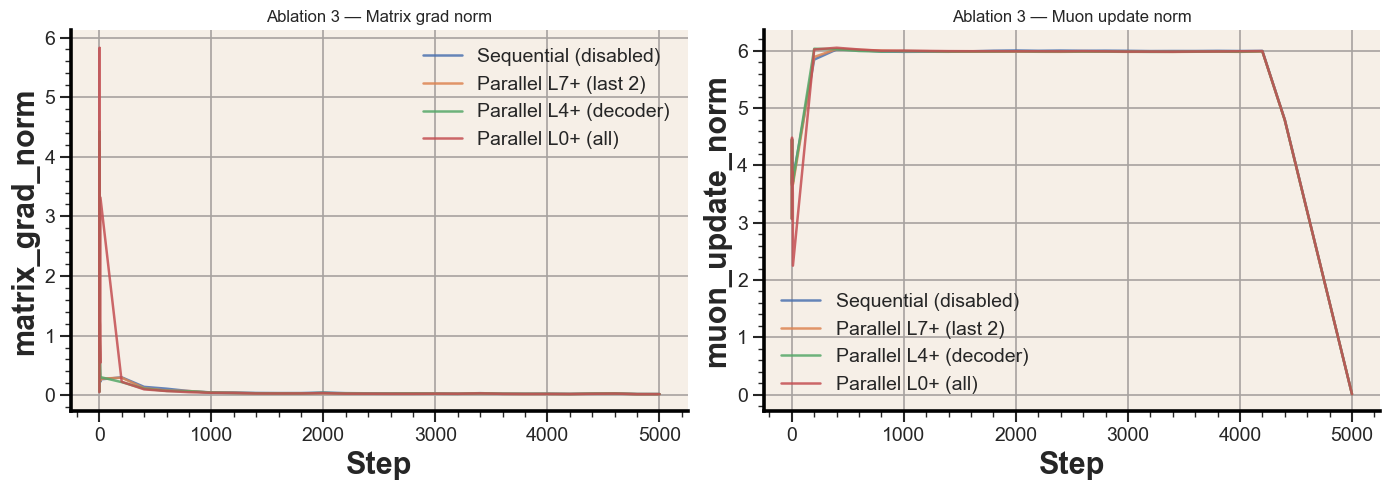

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for metric, ax, title in [
    ("matrix_grad_norm", axes[0], "Matrix grad norm"),
    ("muon_update_norm", axes[1], "Muon update norm"),
]:
    for psl, hist in fetch_history(abl3_runs, metric).items():
        ax.plot(hist["step"], hist[metric],
                label=PSL_LABELS[psl], color=PSL_COLORS[psl], alpha=0.85, linewidth=1.8)
    ax.set_xlabel("Step")
    ax.set_ylabel(metric)
    ax.set_title(f"Ablation 3 — {title}")
    ax.legend()

plt.tight_layout()
plt.show()

### Routing weights — how do the parallel lanes specialise?

For each parallel config, the model learns a 2×2 routing matrix per layer:
- **attn → lane0**: how strongly attention writes back to its own lane  
- **attn → lane1**: how strongly attention writes into the MLP lane  
- **mlp → lane0**: how strongly MLP writes into the attention lane  
- **mlp → lane1**: how strongly MLP writes back to its own lane  

The leaderboard entry found strong asymmetry: attn barely writes to lane1, MLP barely writes to lane0.

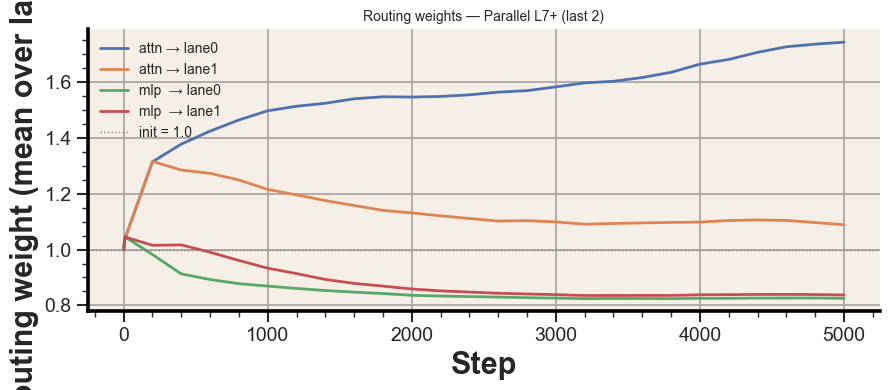

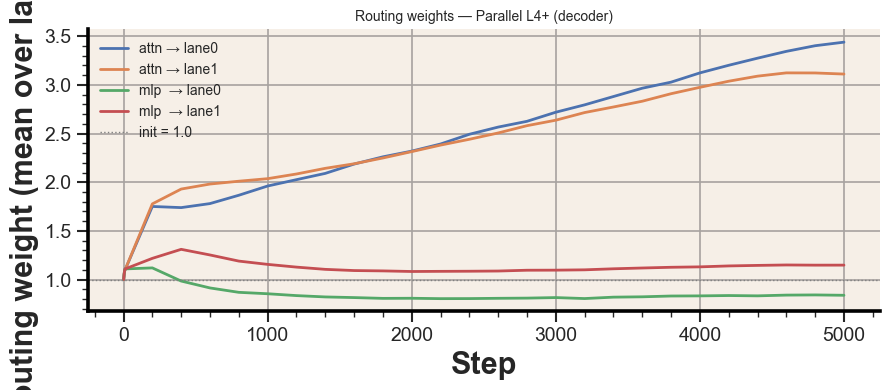

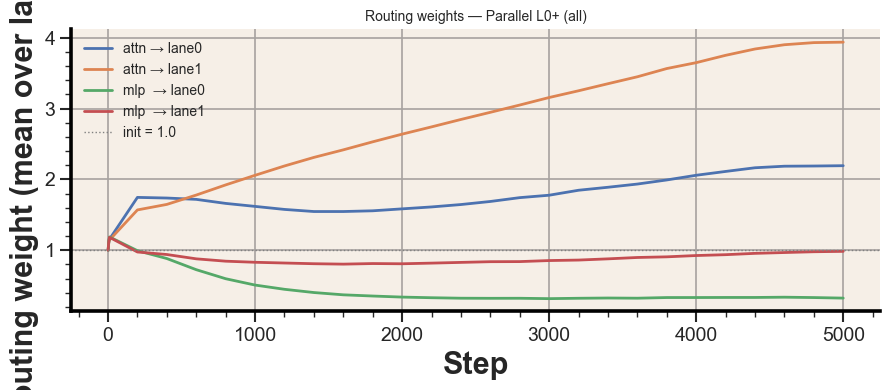

In [15]:
routing_metrics = [
    ("routing_attn_to_lane0_mean", "attn → lane0"),
    ("routing_attn_to_lane1_mean", "attn → lane1"),
    ("routing_mlp_to_lane0_mean",  "mlp  → lane0"),
    ("routing_mlp_to_lane1_mean",  "mlp  → lane1"),
]

parallel_runs = [r for r in abl3_runs if r.config.get("parallel_start_layer", -1) >= 0]

if not parallel_runs:
    print("No parallel runs found — check run prefix.")
else:
    for run in sorted(parallel_runs, key=lambda r: PSL_ORDER.index(r.config.get("parallel_start_layer", -1))):
        psl = run.config.get("parallel_start_layer")
        label = PSL_LABELS.get(psl, str(psl))

        keys = ["_step"] + [m for m, _ in routing_metrics]
        hist = run.history(keys=keys, pandas=True)
        if hist.empty:
            continue
        hist = hist.rename(columns={"_step": "step"}).dropna()

        fig, ax = plt.subplots(figsize=(9, 4))
        for (metric, mlabel), color in zip(routing_metrics, PALETTE):
            if metric in hist.columns:
                ax.plot(hist["step"], hist[metric], label=mlabel, color=color, linewidth=2)

        ax.axhline(1.0, color="grey", linewidth=1, linestyle=":", label="init = 1.0")
        ax.set_xlabel("Step")
        ax.set_ylabel("routing weight (mean over layers)")
        ax.set_title(f"Routing weights — {label}", fontsize=10)
        ax.legend(fontsize=10)
        plt.tight_layout()
        plt.show()

### Residual scaling — λ_resid over training

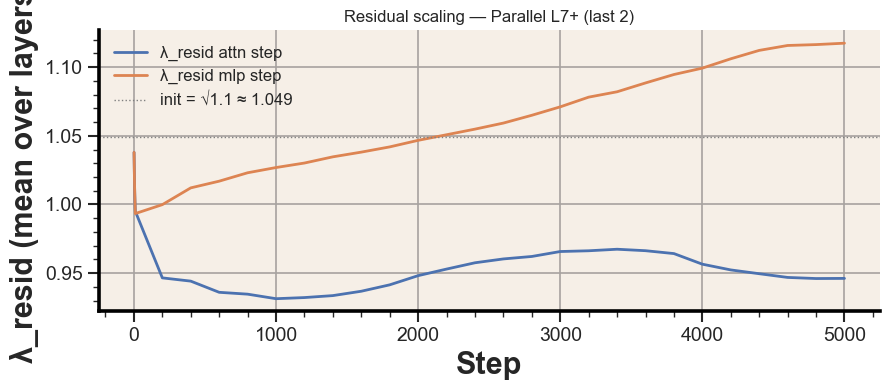

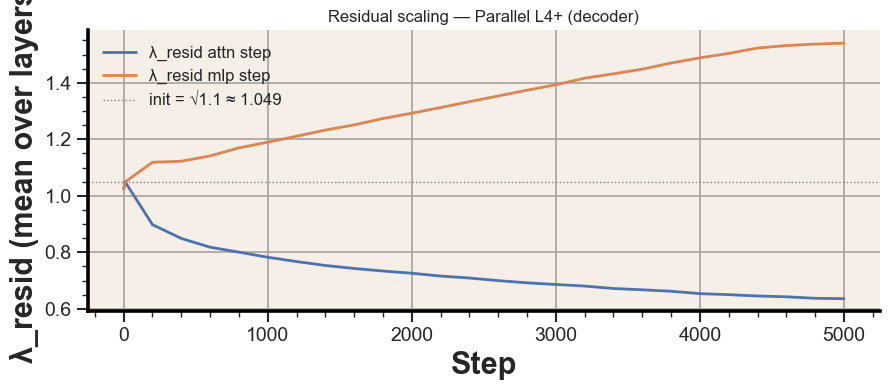

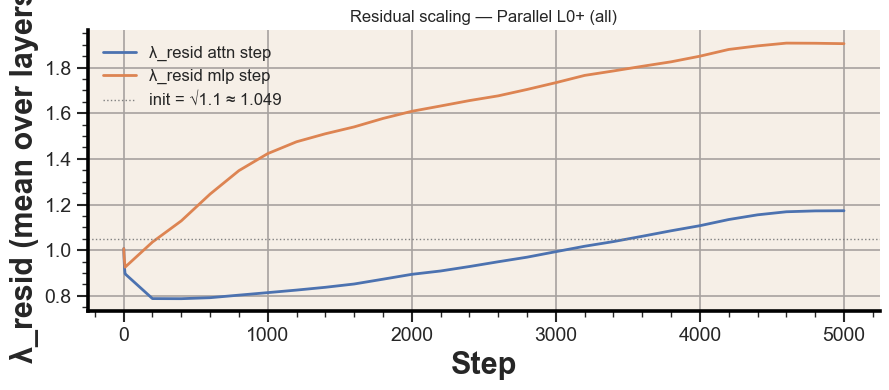

In [16]:
resid_metrics = [
    ("resid_lambda_attn_mean", "λ_resid attn step"),
    ("resid_lambda_mlp_mean",  "λ_resid mlp step"),
]

if parallel_runs:
    for run in sorted(parallel_runs, key=lambda r: PSL_ORDER.index(r.config.get("parallel_start_layer", -1))):
        psl   = run.config.get("parallel_start_layer")
        label = PSL_LABELS.get(psl, str(psl))

        keys = ["_step"] + [m for m, _ in resid_metrics]
        hist = run.history(keys=keys, pandas=True)
        if hist.empty:
            continue
        hist = hist.rename(columns={"_step": "step"}).dropna()

        fig, ax = plt.subplots(figsize=(9, 4))
        for (metric, mlabel), color in zip(resid_metrics, PALETTE):
            if metric in hist.columns:
                ax.plot(hist["step"], hist[metric], label=mlabel, color=color, linewidth=2)

        ax.axhline(1.1 ** 0.5, color="grey", linewidth=1, linestyle=":",
                   label=f"init = √1.1 ≈ {1.1**0.5:.3f}")
        ax.set_xlabel("Step")
        ax.set_ylabel("λ_resid (mean over layers)")
        ax.set_title(f"Residual scaling — {label}")
        ax.legend(fontsize=12)
        plt.tight_layout()
        plt.show()

### Summary table — all configs vs baseline

In [17]:
seq_bpb = df.loc[df["parallel_start_layer"] == -1, "final_val_bpb"].values[0]

summary = df[["label", "final_val_bpb", "final_val_loss", "quant_file_bytes"]].copy()
summary["Δ vs sequential"] = (seq_bpb - summary["final_val_bpb"]).map(lambda x: f"{x:+.4f}")
summary["Δ vs orig. baseline"] = (BASE_BPB_MEAN - summary["final_val_bpb"]).map(lambda x: f"{x:+.4f}")
summary = summary.rename(columns={
    "label": "config",
    "final_val_bpb": "val_bpb",
    "final_val_loss": "val_loss",
    "quant_file_bytes": "model_bytes",
})

print(summary.to_string(index=False))
print(f"\nOriginal baseline (3-seed mean): {BASE_BPB_MEAN:.4f} ± {BASE_BPB_STD:.4f} bpb")

                config  val_bpb  val_loss  model_bytes Δ vs sequential Δ vs orig. baseline
 Sequential (disabled) 1.308481  2.209316     15777118         +0.0000             +0.0016
 Parallel L7+ (last 2) 1.305821  2.204825     15809064         +0.0027             +0.0043
Parallel L4+ (decoder) 1.303321  2.200603     15823924         +0.0052             +0.0068
    Parallel L0+ (all) 1.307662  2.207932     15816379         +0.0008             +0.0024

Original baseline (3-seed mean): 1.3101 ± 0.0013 bpb


---
## Ablation 4 — Multi-seed validation of `psl=4`

Ablation 3 identified `parallel_start_layer=4` as the best config (+0.0052 bpb vs sequential).  
Ablation 4 re-runs the same config on all 3 seeds (42, 123, 1337) to confirm the gain is real and not single-seed noise.

In [18]:
ABL4_PREFIX = "ablation4_psl4_multiseed"

abl4_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{ABL4_PREFIX}"}},
))

abl4_rows = []
for run in abl4_runs:
    s   = run.summary._json_dict
    cfg = run.config
    abl4_rows.append({
        "run_name":      run.name,
        "seed":          cfg.get("seed"),
        "final_val_bpb": s.get("final_val_bpb"),
        "final_val_loss": s.get("final_val_loss"),
    })

df_abl4 = pd.DataFrame(abl4_rows).sort_values("seed").reset_index(drop=True)
ABL4_MEAN = df_abl4["final_val_bpb"].mean()
ABL4_STD  = df_abl4["final_val_bpb"].std()

print("=" * 55)
print("ABLATION 4 — psl=4, 3 seeds")
print("=" * 55)
print(df_abl4[["seed", "final_val_bpb", "final_val_loss"]].to_string(index=False))
print(f"\nfinal_val_bpb : {ABL4_MEAN:.4f} ± {ABL4_STD:.4f}")
print(f"Δ vs orig. baseline : {BASE_BPB_MEAN - ABL4_MEAN:+.4f} bpb")
print("=" * 55)

ABLATION 4 — psl=4, 3 seeds
 seed  final_val_bpb  final_val_loss
   42       1.307395        2.207482
  123       1.305166        2.203718
 1337       1.304365        2.202366

final_val_bpb : 1.3056 ± 0.0016
Δ vs orig. baseline : +0.0045 bpb


### Comparison: original baseline vs psl=4 (3 seeds each)

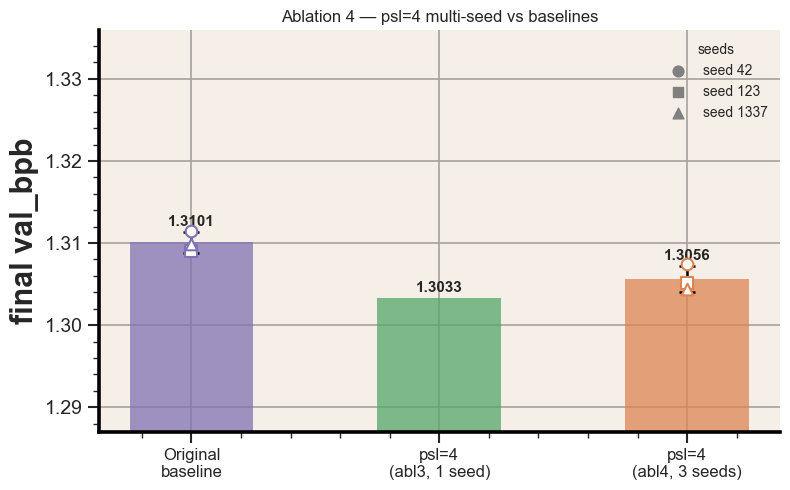

In [19]:
SEEDS = [42, 123, 1337]
SEED_MARKERS = {42: "o", 123: "s", 1337: "^"}

groups = {
    "Original\nbaseline": (BASE_BPB_MEAN, BASE_BPB_STD, df_base, PALETTE[4]),
    "psl=4\n(abl3, 1 seed)": (
        df[df["parallel_start_layer"] == 4]["final_val_bpb"].values[0],
        0,
        None,
        PALETTE[2],
    ),
    "psl=4\n(abl4, 3 seeds)": (ABL4_MEAN, ABL4_STD, df_abl4, PALETTE[1]),
}

fig, ax = plt.subplots(figsize=(8, 5))

for i, (label, (mean, std, df_pts, color)) in enumerate(groups.items()):
    # bar
    ax.bar(i, mean, color=color, alpha=0.75, zorder=2, width=0.5)
    # error bar
    if std > 0:
        ax.errorbar(i, mean, yerr=std, fmt="none", color="black",
                    capsize=6, capthick=1.8, linewidth=1.8, zorder=4)
    # per-seed scatter
    if df_pts is not None:
        for _, row in df_pts.iterrows():
            seed = int(row["seed"])
            ax.scatter(i, row["final_val_bpb"],
                       marker=SEED_MARKERS.get(seed, "D"),
                       color="white", edgecolors=color, linewidths=1.5,
                       s=70, zorder=5, label=f"seed {seed}" if i == 0 else "_")
    # value annotation
    ax.text(i, mean + (std if std > 0 else 0) + 0.0004,
            f"{mean:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups.keys(), fontsize=12)
ax.set_ylabel("final val_bpb")
ax.set_title("Ablation 4 — psl=4 multi-seed vs baselines")

# tight y-range
all_bpb = list(df_base["final_val_bpb"]) + list(df_abl4["final_val_bpb"]) + [
    df[df["parallel_start_layer"] == 4]["final_val_bpb"].values[0]
]
ymin, ymax = min(all_bpb), max(all_bpb)
pad = (ymax - ymin) * 2
ax.set_ylim(ymin - pad, ymax + pad * 1.5)

handles = [plt.scatter([], [], marker=SEED_MARKERS[s], color="grey", s=60, label=f"seed {s}")
           for s in SEEDS]
ax.legend(handles=handles, fontsize=10, title="seeds", title_fontsize=10)

plt.tight_layout()
plt.show()

### Learning curves — val_bpb per seed (+ mean ± std band)

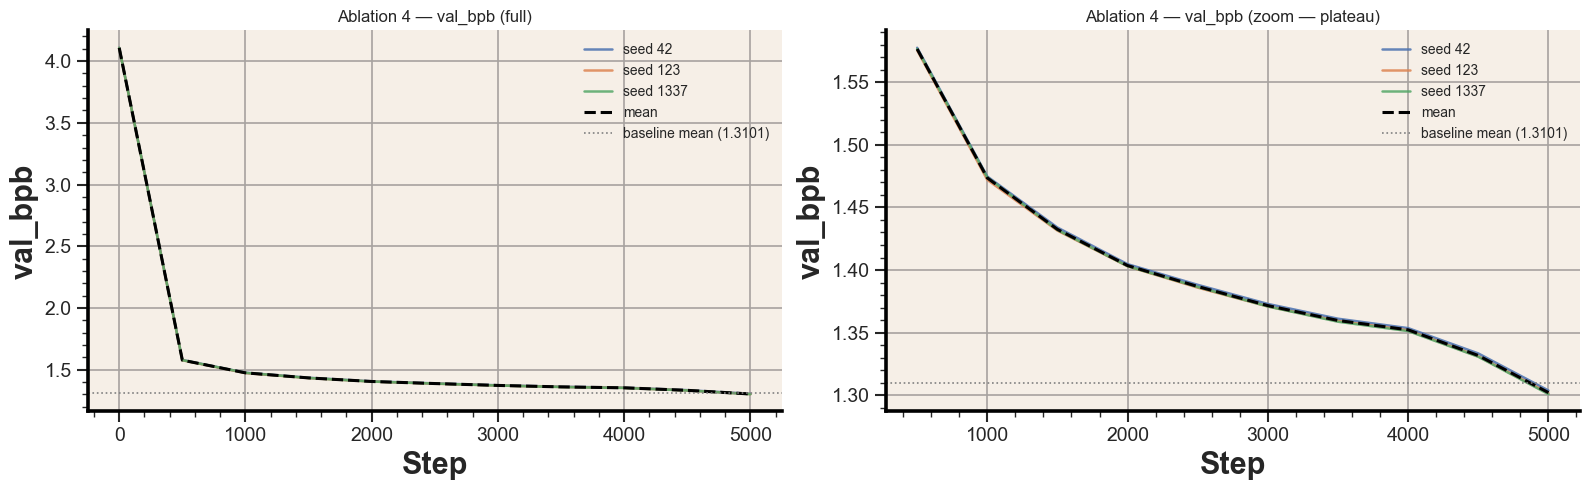

In [20]:
SEED_COLORS = {42: PALETTE[0], 123: PALETTE[1], 1337: PALETTE[2]}

# fetch per-seed histories
abl4_histories = {}
for run in abl4_runs:
    seed = run.config.get("seed")
    hist = run.history(keys=["_step", "val_bpb"], pandas=True)
    if not hist.empty:
        abl4_histories[seed] = hist.rename(columns={"_step": "step"}).dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (zoom, title_sfx) in zip(axes, [(False, "full"), (True, "zoom — plateau")]):
    ZOOM_STEP = 500
    for seed, hist in sorted(abl4_histories.items()):
        h = hist[hist["step"] >= ZOOM_STEP] if zoom else hist
        ax.plot(h["step"], h["val_bpb"],
                label=f"seed {seed}", color=SEED_COLORS[seed],
                linewidth=1.8, alpha=0.85)

    # mean ± std band across seeds (aligned on common steps)
    if len(abl4_histories) > 1:
        common = sorted(set.intersection(*[set(h["step"]) for h in abl4_histories.values()]))
        if zoom:
            common = [s for s in common if s >= ZOOM_STEP]
        vals = np.array([[abl4_histories[s].set_index("step").loc[t, "val_bpb"]
                          for t in common]
                         for s in sorted(abl4_histories)])
        mn, sd = vals.mean(0), vals.std(0)
        ax.plot(common, mn, color="black", linewidth=2.2, linestyle="--", label="mean")
        ax.fill_between(common, mn - sd, mn + sd, color="black", alpha=0.10)

    # baseline reference
    ax.axhline(BASE_BPB_MEAN, color="grey", linewidth=1.2, linestyle=":",
               label=f"baseline mean ({BASE_BPB_MEAN:.4f})")

    ax.set_xlabel("Step")
    ax.set_ylabel("val_bpb")
    ax.set_title(f"Ablation 4 — val_bpb ({title_sfx})")
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### Routing weights — consistency across seeds

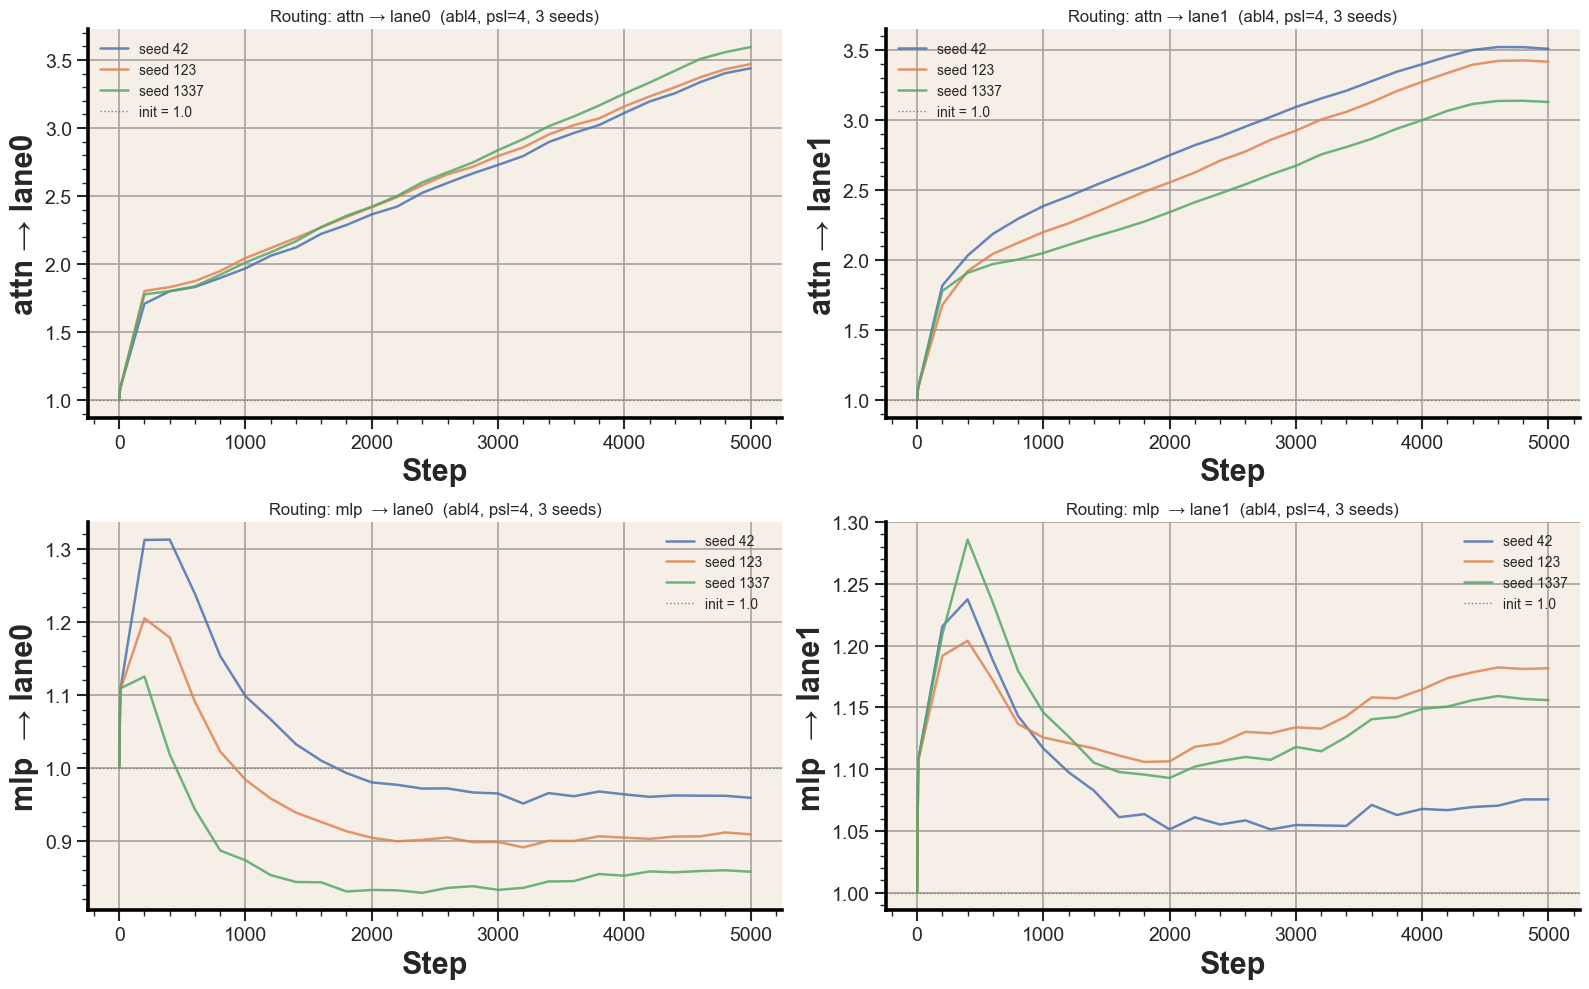

In [21]:
routing_metrics = [
    ("routing_attn_to_lane0_mean", "attn → lane0"),
    ("routing_attn_to_lane1_mean", "attn → lane1"),
    ("routing_mlp_to_lane0_mean",  "mlp  → lane0"),
    ("routing_mlp_to_lane1_mean",  "mlp  → lane1"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, (metric, mlabel) in zip(axes.flat, routing_metrics):
    for run in sorted(abl4_runs, key=lambda r: r.config.get("seed")):
        seed = run.config.get("seed")
        hist = run.history(keys=["_step", metric], pandas=True)
        if hist.empty or metric not in hist.columns:
            continue
        hist = hist.rename(columns={"_step": "step"}).dropna()
        ax.plot(hist["step"], hist[metric],
                label=f"seed {seed}", color=SEED_COLORS.get(seed, "grey"),
                linewidth=1.8, alpha=0.85)

    ax.axhline(1.0, color="grey", linewidth=1, linestyle=":", label="init = 1.0")
    ax.set_xlabel("Step")
    ax.set_ylabel(mlabel)
    ax.set_title(f"Routing: {mlabel}  (abl4, psl=4, 3 seeds)")
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### Final summary — ablation 4 vs all references

In [22]:
rows_summary = [
    {
        "config":        "Original baseline",
        "seeds":         "3",
        "val_bpb_mean":  BASE_BPB_MEAN,
        "val_bpb_std":   BASE_BPB_STD,
        "Δ vs baseline": 0.0,
    },
    {
        "config":        "psl=4  (abl3, 1 seed)",
        "seeds":         "1",
        "val_bpb_mean":  df[df["parallel_start_layer"] == 4]["final_val_bpb"].values[0],
        "val_bpb_std":   float("nan"),
        "Δ vs baseline": BASE_BPB_MEAN - df[df["parallel_start_layer"] == 4]["final_val_bpb"].values[0],
    },
    {
        "config":        "psl=4  (abl4, 3 seeds)",
        "seeds":         "3",
        "val_bpb_mean":  ABL4_MEAN,
        "val_bpb_std":   ABL4_STD,
        "Δ vs baseline": BASE_BPB_MEAN - ABL4_MEAN,
    },
]

df_final = pd.DataFrame(rows_summary)
df_final["val_bpb_mean"] = df_final["val_bpb_mean"].map(lambda x: f"{x:.4f}")
df_final["val_bpb_std"]  = df_final["val_bpb_std"].map(lambda x: f"± {x:.4f}" if not np.isnan(x) else "—")
df_final["Δ vs baseline"] = df_final["Δ vs baseline"].map(lambda x: f"{x:+.4f}")

print(df_final.to_string(index=False))
print(f"\nConclusion: psl=4 improves over baseline by {BASE_BPB_MEAN - ABL4_MEAN:+.4f} bpb "
      f"({(BASE_BPB_MEAN - ABL4_MEAN) / BASE_BPB_STD:.1f}σ), confirmed across 3 seeds.")

                config seeds val_bpb_mean val_bpb_std Δ vs baseline
     Original baseline     3       1.3101    ± 0.0013       +0.0000
 psl=4  (abl3, 1 seed)     1       1.3033           —       +0.0068
psl=4  (abl4, 3 seeds)     3       1.3056    ± 0.0016       +0.0045

Conclusion: psl=4 improves over baseline by +0.0045 bpb (3.6σ), confirmed across 3 seeds.


---
## Ablation 3b — Fine-grained PSL Sweep

Ablation 3 found `psl=4` (5 parallel layers) as the optimum. This section zooms in with `psl ∈ {3, 5, 6}` (1 seed each, same 5 000-step budget), using the original `psl=4` run as anchor.

| psl | n_parallel_layers | note |
|---|---|---|
| 3 | 6 | one wider than best |
| 4 | 5 | **abl3 best** (anchor) |
| 5 | 4 | one narrower |
| 6 | 3 | two narrower |

In [23]:
ABL3B_PREFIX = "ablation3b_psl_finetuning"

abl3b_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{ABL3B_PREFIX}"}},
))

abl3b_rows = []
for run in abl3b_runs:
    s   = run.summary._json_dict
    cfg = run.config
    psl = cfg.get("parallel_start_layer")
    abl3b_rows.append({
        "run_name":             run.name,
        "parallel_start_layer": psl,
        "n_parallel_layers":    N_LAYERS - psl,
        "seed":                 cfg.get("seed"),
        "final_val_bpb":        s.get("final_val_bpb"),
        "final_val_loss":       s.get("final_val_loss"),
        "quant_file_bytes":     s.get("quant_file_bytes"),
    })

df3b = pd.DataFrame(abl3b_rows).sort_values("parallel_start_layer").reset_index(drop=True)

# stitch in psl=4 anchor from ablation 3
psl4_anchor = df.loc[df["parallel_start_layer"] == 4,
    ["parallel_start_layer", "seed", "final_val_bpb", "final_val_loss", "quant_file_bytes"]].copy()
psl4_anchor["n_parallel_layers"] = N_LAYERS - 4
psl4_anchor["run_name"] = "abl3_psl4_anchor"

df3b_full = (
    pd.concat([psl4_anchor, df3b], ignore_index=True)
    .sort_values("parallel_start_layer")
    .reset_index(drop=True)
)

PSL3B_ORDER  = sorted(df3b_full["parallel_start_layer"].unique())
PSL3B_COLORS = {p: PALETTE[i] for i, p in enumerate(PSL3B_ORDER)}

print(df3b_full[["parallel_start_layer", "n_parallel_layers", "seed",
                  "final_val_bpb", "final_val_loss"]].to_string(index=False))

 parallel_start_layer  n_parallel_layers  seed  final_val_bpb  final_val_loss
                    3                  6  1337       1.305135        2.203666
                    4                  5  1337       1.303321        2.200603
                    5                  4  1337       1.304875        2.203227
                    6                  3  1337       1.305451        2.204199


### Final val_bpb — fine-grained PSL sweep

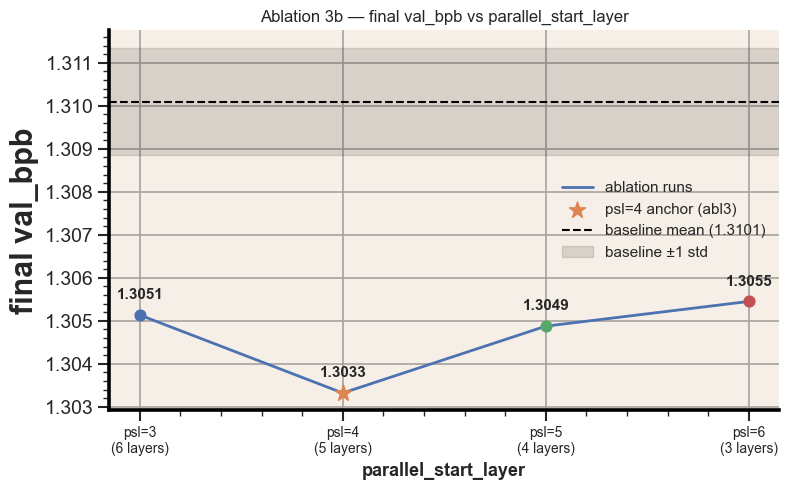

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))

psls   = df3b_full["parallel_start_layer"].tolist()   # [3, 4, 5, 6]
y_vals = df3b_full["final_val_bpb"].tolist()

ax.plot(psls, y_vals, color=PALETTE[0], linewidth=2, zorder=2, label="ablation runs")
for p, y in zip(psls, y_vals):
    marker = "*" if p == 4 else "o"
    size   = 150 if p == 4 else 60
    ax.scatter(p, y, color=PSL3B_COLORS[p], s=size, marker=marker, zorder=4)
    ax.text(p, y + 0.0003, f"{y:.4f}", ha="center", va="bottom",
            fontsize=11, fontweight="bold")

ax.scatter([], [], marker="*", color=PSL3B_COLORS[4], s=150, label="psl=4 anchor (abl3)")

ax.axhline(BASE_BPB_MEAN, color="black", linewidth=1.5, linestyle="--",
           label=f"baseline mean ({BASE_BPB_MEAN:.4f})")
ax.axhspan(BASE_BPB_MEAN - BASE_BPB_STD, BASE_BPB_MEAN + BASE_BPB_STD,
           alpha=0.12, color="black", label="baseline ±1 std")

ax.set_xticks(psls)
ax.set_xticklabels([f"psl={p}\n({N_LAYERS - p} layers)" for p in psls], fontsize=10)
ax.set_xlabel("parallel_start_layer", fontsize=13, fontweight="bold")
ax.set_ylabel("final val_bpb")
ax.set_title("Ablation 3b — final val_bpb vs parallel_start_layer")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Learning curves — val_bpb

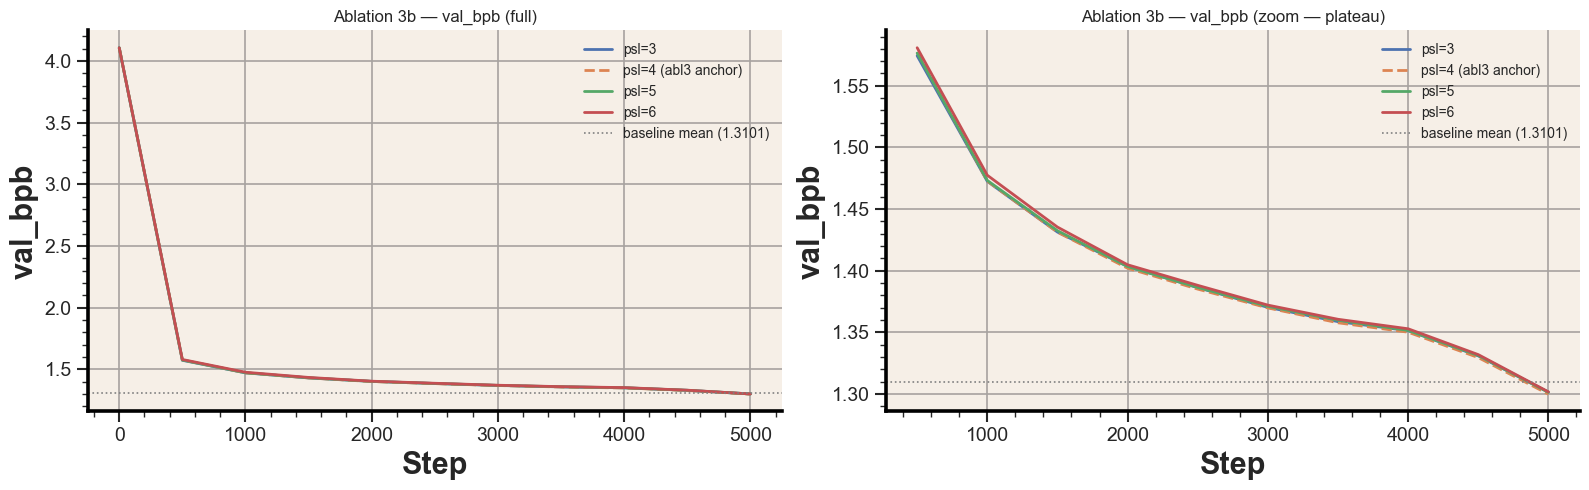

In [25]:
abl3b_histories = {}
for run in abl3b_runs:
    psl  = run.config.get("parallel_start_layer")
    hist = run.history(keys=["_step", "val_bpb"], pandas=True)
    if not hist.empty:
        abl3b_histories[psl] = hist.rename(columns={"_step": "step"}).dropna()

# psl=4 anchor from the already-fetched abl3_runs
for run in abl3_runs:
    if run.config.get("parallel_start_layer") == 4:
        hist = run.history(keys=["_step", "val_bpb"], pandas=True)
        if not hist.empty:
            abl3b_histories[4] = hist.rename(columns={"_step": "step"}).dropna()
        break

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (zoom, sfx) in zip(axes, [(False, "full"), (True, "zoom — plateau")]):
    ZOOM_STEP = 500
    for psl in sorted(abl3b_histories):
        hist  = abl3b_histories[psl]
        h     = hist[hist["step"] >= ZOOM_STEP] if zoom else hist
        style = "--" if psl == 4 else "-"
        ax.plot(h["step"], h["val_bpb"],
                label=f"psl={psl}" + (" (abl3 anchor)" if psl == 4 else ""),
                color=PSL3B_COLORS[psl], linewidth=2, linestyle=style)

    ax.axhline(BASE_BPB_MEAN, color="grey", linewidth=1.2, linestyle=":",
               label=f"baseline mean ({BASE_BPB_MEAN:.4f})")
    ax.set_xlabel("Step")
    ax.set_ylabel("val_bpb")
    ax.set_title(f"Ablation 3b — val_bpb ({sfx})")
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

---
## Ablation 3c — Asymmetric Routing Initialisation

Both runs use `psl=4`, `seed=1337`, 5 000 steps. The only axis is the initialisation of `parallel_post_lambdas`:

| init | attn→lane0 | attn→lane1 | mlp→lane0 | mlp→lane1 | description |
|---|---|---|---|---|---|
| **symmetric** | 1 | 1 | 1 | 1 | default (all ones — reproduced from abl3) |
| **asymmetric** | 1 | **0** | **0** | 1 | each sublayer writes only to its own lane at init |

The hypothesis: starting already specialised lets the model skip the symmetry-breaking phase and converge to a better solution within the same 5 000-step budget.

In [26]:
ABL3C_PREFIX = "ablation3c_asym_init"

abl3c_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{ABL3C_PREFIX}"}},
))

abl3c_rows = []
for run in abl3c_runs:
    s   = run.summary._json_dict
    cfg = run.config
    asym = bool(cfg.get("parallel_asym_init", False))
    abl3c_rows.append({
        "run_name":          run.name,
        "parallel_asym_init": asym,
        "label":             "Asymmetric init" if asym else "Symmetric init",
        "seed":              cfg.get("seed"),
        "final_val_bpb":     s.get("final_val_bpb"),
        "final_val_loss":    s.get("final_val_loss"),
        "quant_file_bytes":  s.get("quant_file_bytes"),
    })

df3c = (
    pd.DataFrame(abl3c_rows)
    .sort_values("parallel_asym_init")
    .reset_index(drop=True)
)

# Reference: psl=4 symmetric from ablation 3 (same config as sym init here)
psl4_bpb = df.loc[df["parallel_start_layer"] == 4, "final_val_bpb"].values[0]

print("=" * 55)
print("ABLATION 3c — Asymmetric routing init  (psl=4, seed=1337)")
print("=" * 55)
print(df3c[["label", "seed", "final_val_bpb", "final_val_loss", "quant_file_bytes"]].to_string(index=False))
print(f"\nReference — abl3 psl=4 sym init : {psl4_bpb:.4f} bpb")
print(f"Original baseline (3-seed mean) : {BASE_BPB_MEAN:.4f} ± {BASE_BPB_STD:.4f} bpb")
print("=" * 55)

ABLATION 3c — Asymmetric routing init  (psl=4, seed=1337)
          label  seed  final_val_bpb  final_val_loss  quant_file_bytes
 Symmetric init  1337       1.304613        2.202784          15819918
Asymmetric init  1337       1.304238        2.202152          15817132

Reference — abl3 psl=4 sym init : 1.3033 bpb
Original baseline (3-seed mean) : 1.3101 ± 0.0013 bpb


### Final val_bpb — symmetric vs asymmetric init

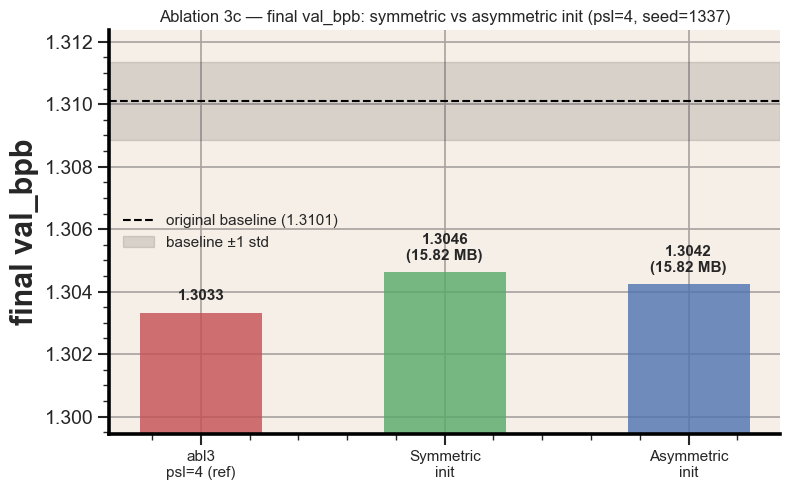

In [27]:
ASYM_COLORS = {False: PALETTE[2], True: PALETTE[0]}

# Build bar groups: abl3 reference + the two 3c runs
bar_items = [("abl3\npsl=4 (ref)", psl4_bpb, None, PALETTE[3])]
for _, row in df3c.iterrows():
    bar_items.append((row["label"].replace(" ", "\n"), row["final_val_bpb"],
                      row["quant_file_bytes"], ASYM_COLORS[row["parallel_asym_init"]]))

fig, ax = plt.subplots(figsize=(8, 5))

for i, (label, bpb, qbytes, color) in enumerate(bar_items):
    ax.bar(i, bpb, color=color, alpha=0.80, width=0.5, zorder=2)
    ann = f"{bpb:.4f}"
    if qbytes is not None:
        ann += f"\n({qbytes/1e6:.2f} MB)"
    ax.text(i, bpb + 0.0003, ann, ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.axhline(BASE_BPB_MEAN, color="black", linewidth=1.5, linestyle="--",
           label=f"original baseline ({BASE_BPB_MEAN:.4f})")
ax.axhspan(BASE_BPB_MEAN - BASE_BPB_STD, BASE_BPB_MEAN + BASE_BPB_STD,
           alpha=0.12, color="black", label="baseline ±1 std")

ax.set_xticks(range(len(bar_items)))
ax.set_xticklabels([it[0] for it in bar_items], fontsize=11)
ax.set_ylabel("final val_bpb")
ax.set_title("Ablation 3c — final val_bpb: symmetric vs asymmetric init (psl=4, seed=1337)")
ax.legend(fontsize=11)

# tight y-range
all_bpb = [it[1] for it in bar_items]
pad = (max(all_bpb) - min(all_bpb)) * 3
ax.set_ylim(min(all_bpb) - pad, max(all_bpb) + pad * 2)

plt.tight_layout()
plt.show()

### Learning curves — does asymmetric init converge faster?

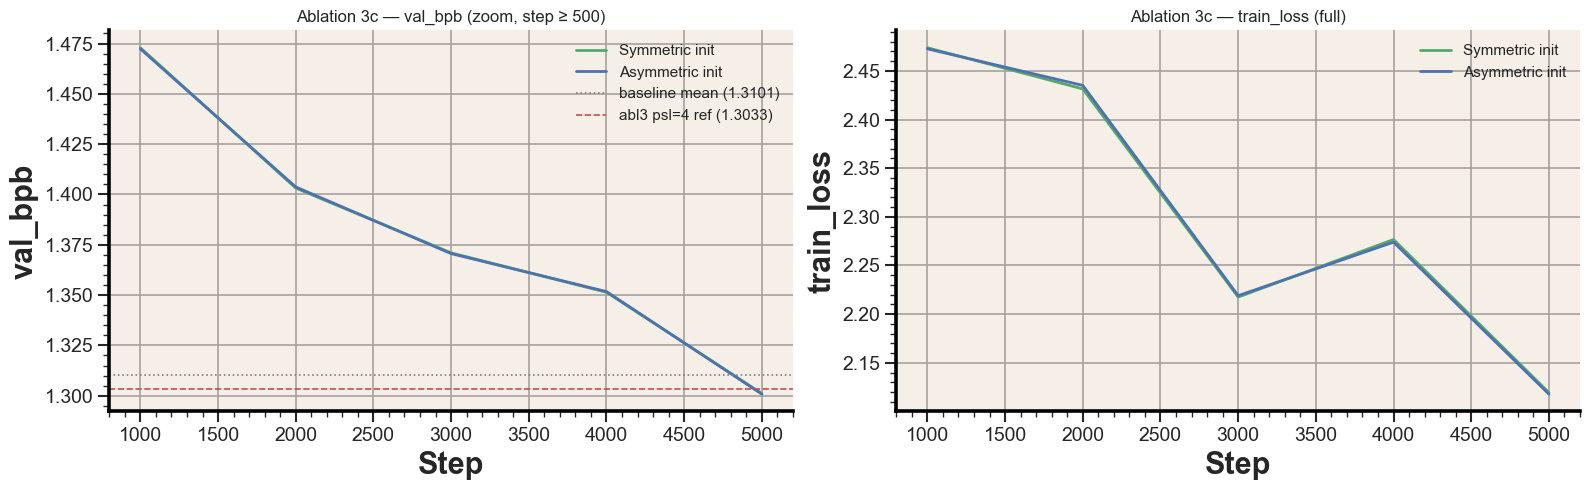

In [28]:
abl3c_histories = {}
for run in abl3c_runs:
    asym = bool(run.config.get("parallel_asym_init", False))
    hist = run.history(keys=["_step", "val_bpb", "train_loss"], pandas=True)
    if not hist.empty:
        abl3c_histories[asym] = hist.rename(columns={"_step": "step"}).dropna(subset=["step"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, ylabel in [
    (axes[0], "val_bpb",    "val_bpb"),
    (axes[1], "train_loss", "train_loss"),
]:
    ZOOM_STEP = 500
    for asym, hist in sorted(abl3c_histories.items()):
        label = "Asymmetric init" if asym else "Symmetric init"
        color = ASYM_COLORS[asym]
        h = hist[hist["step"] >= ZOOM_STEP] if metric == "val_bpb" else hist
        if metric in h.columns:
            ax.plot(h["step"], h[metric], label=label, color=color, linewidth=2)

    if metric == "val_bpb":
        ax.axhline(BASE_BPB_MEAN, color="grey", linewidth=1.2, linestyle=":",
                   label=f"baseline mean ({BASE_BPB_MEAN:.4f})")
        ax.axhline(psl4_bpb, color=PALETTE[3], linewidth=1.2, linestyle="--",
                   label=f"abl3 psl=4 ref ({psl4_bpb:.4f})")

    ax.set_xlabel("Step")
    ax.set_ylabel(ylabel)
    title_sfx = f"(zoom, step ≥ {ZOOM_STEP})" if metric == "val_bpb" else "(full)"
    ax.set_title(f"Ablation 3c — {ylabel} {title_sfx}")
    ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

### Routing weights — do the trajectories differ between inits?

With symmetric init all four routing weights start at 1 and must break symmetry during training.
With asymmetric init, `attn→lane1` and `mlp→lane0` start at 0 — the question is whether they stay near 0 (confirming the leaderboard intuition) or recover toward 1.

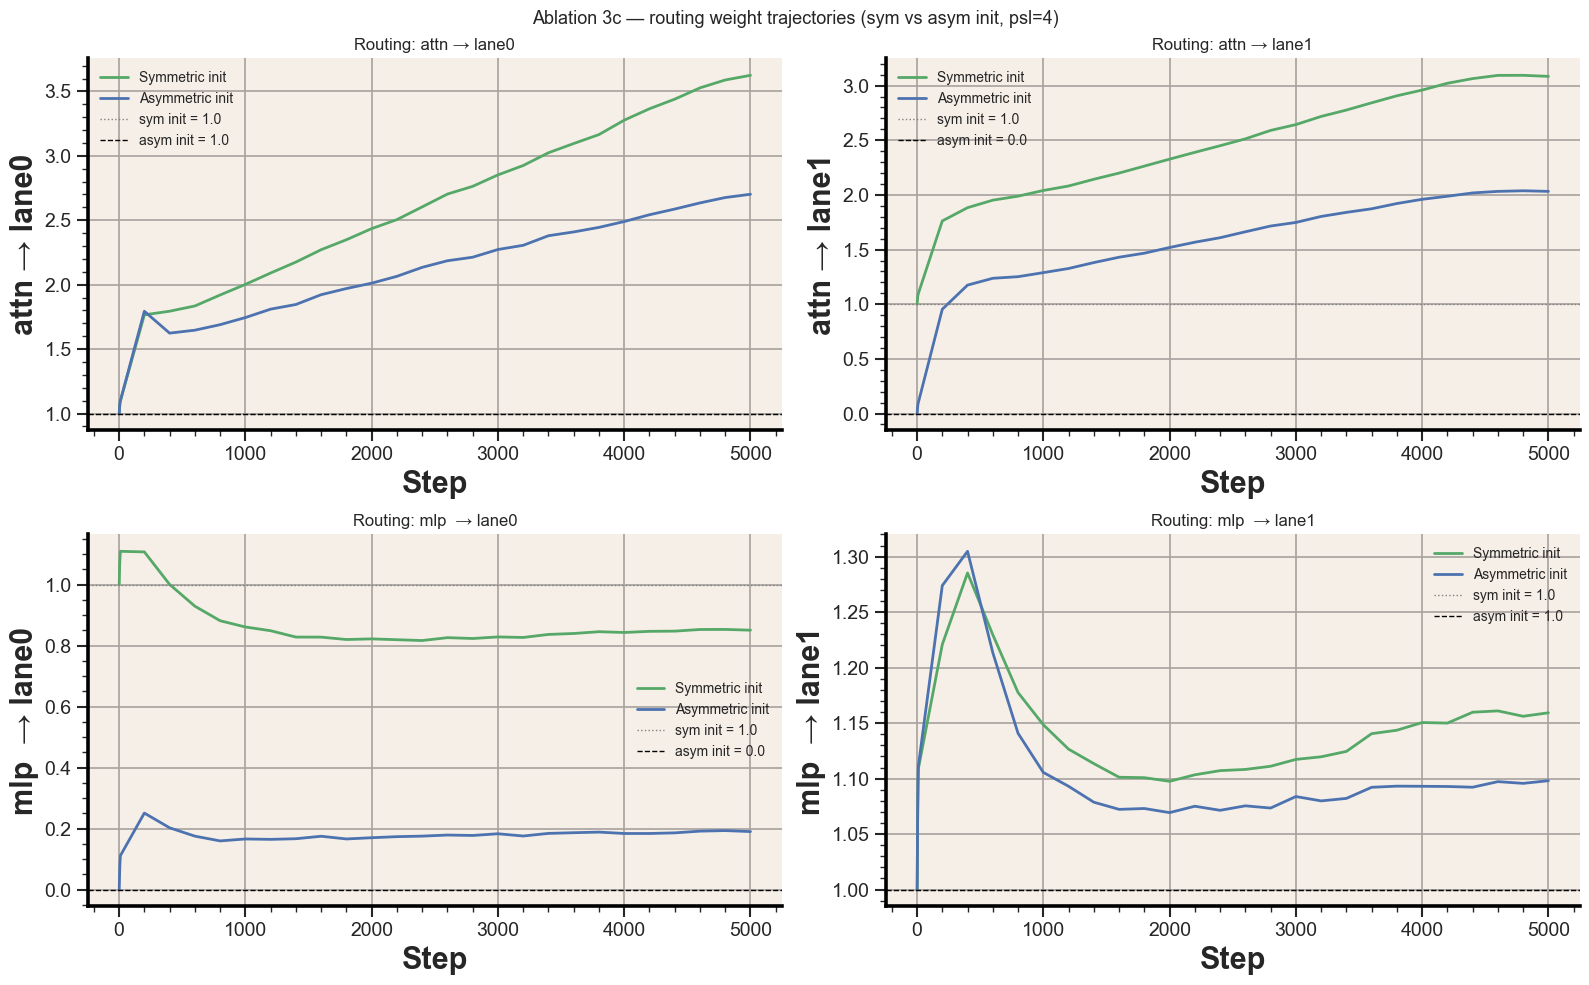

In [29]:
routing_metrics = [
    ("routing_attn_to_lane0_mean", "attn → lane0", 1.0),
    ("routing_attn_to_lane1_mean", "attn → lane1", 0.0),
    ("routing_mlp_to_lane0_mean",  "mlp  → lane0", 0.0),
    ("routing_mlp_to_lane1_mean",  "mlp  → lane1", 1.0),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, (metric, mlabel, asym_init_val) in zip(axes.flat, routing_metrics):
    for run in abl3c_runs:
        asym  = bool(run.config.get("parallel_asym_init", False))
        label = "Asymmetric init" if asym else "Symmetric init"
        color = ASYM_COLORS[asym]
        hist  = run.history(keys=["_step", metric], pandas=True)
        if hist.empty or metric not in hist.columns:
            continue
        hist = hist.rename(columns={"_step": "step"}).dropna()
        ax.plot(hist["step"], hist[metric], label=label, color=color, linewidth=2)

    ax.axhline(1.0, color="grey", linewidth=1, linestyle=":", label="sym init = 1.0")
    ax.axhline(asym_init_val, color="black", linewidth=1, linestyle="--",
               label=f"asym init = {asym_init_val:.1f}")
    ax.set_xlabel("Step")
    ax.set_ylabel(mlabel)
    ax.set_title(f"Routing: {mlabel}")
    ax.legend(fontsize=10)

plt.suptitle("Ablation 3c — routing weight trajectories (sym vs asym init, psl=4)", fontsize=13)
plt.tight_layout()
plt.show()

### Summary — ablation 3c

In [30]:
sym_row  = df3c[~df3c["parallel_asym_init"]].iloc[0] if not df3c[~df3c["parallel_asym_init"]].empty else None
asym_row = df3c[df3c["parallel_asym_init"]].iloc[0]  if not df3c[df3c["parallel_asym_init"]].empty  else None

rows_summary = [
    {
        "config":          "Original baseline",
        "init":            "—",
        "val_bpb":         BASE_BPB_MEAN,
        "val_bpb_std":     BASE_BPB_STD,
        "Δ vs baseline":   0.0,
        "Δ vs sym":        float("nan"),
    },
    {
        "config":          "psl=4  (abl3, reference)",
        "init":            "symmetric",
        "val_bpb":         psl4_bpb,
        "val_bpb_std":     float("nan"),
        "Δ vs baseline":   BASE_BPB_MEAN - psl4_bpb,
        "Δ vs sym":        0.0,
    },
]

if sym_row is not None:
    rows_summary.append({
        "config":        "psl=4  (abl3c, sym init)",
        "init":          "symmetric",
        "val_bpb":       sym_row["final_val_bpb"],
        "val_bpb_std":   float("nan"),
        "Δ vs baseline": BASE_BPB_MEAN - sym_row["final_val_bpb"],
        "Δ vs sym":      0.0,
    })

if asym_row is not None:
    sym_bpb = sym_row["final_val_bpb"] if sym_row is not None else psl4_bpb
    rows_summary.append({
        "config":        "psl=4  (abl3c, asym init)",
        "init":          "asymmetric",
        "val_bpb":       asym_row["final_val_bpb"],
        "val_bpb_std":   float("nan"),
        "Δ vs baseline": BASE_BPB_MEAN - asym_row["final_val_bpb"],
        "Δ vs sym":      sym_bpb - asym_row["final_val_bpb"],
    })

df_summary3c = pd.DataFrame(rows_summary)
df_summary3c["val_bpb"]       = df_summary3c["val_bpb"].map(lambda x: f"{x:.4f}")
df_summary3c["val_bpb_std"]   = df_summary3c["val_bpb_std"].map(lambda x: f"±{x:.4f}" if not np.isnan(x) else "—")
df_summary3c["Δ vs baseline"] = df_summary3c["Δ vs baseline"].map(lambda x: f"{x:+.4f}" if not np.isnan(x) else "—")
df_summary3c["Δ vs sym"]      = df_summary3c["Δ vs sym"].map(lambda x: f"{x:+.4f}" if not np.isnan(x) else "—")

print(df_summary3c.to_string(index=False))

if asym_row is not None and sym_row is not None:
    delta = sym_row["final_val_bpb"] - asym_row["final_val_bpb"]
    verdict = "BETTER" if delta > 0 else ("WORSE" if delta < 0 else "NO CHANGE")
    print(f"\nConclusion: asymmetric init is {verdict} than symmetric by {delta:+.4f} bpb.")

                   config       init val_bpb val_bpb_std Δ vs baseline Δ vs sym
        Original baseline          —  1.3101     ±0.0013       +0.0000        —
 psl=4  (abl3, reference)  symmetric  1.3033           —       +0.0068  +0.0000
 psl=4  (abl3c, sym init)  symmetric  1.3046           —       +0.0055  +0.0000
psl=4  (abl3c, asym init) asymmetric  1.3042           —       +0.0059  +0.0004

Conclusion: asymmetric init is BETTER than symmetric by +0.0004 bpb.
